# 03 — HSV Color Histogram Feature Extraction (Final)

### Import Libraries

In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from torchvision.datasets import GTSRB

### Load GTSRB

In [2]:
DATA_DIR = Path("../data")

train_dataset = GTSRB(
    root=DATA_DIR,
    split="train",
    download=False
)

test_dataset = GTSRB(
    root=DATA_DIR,
    split="test",
    download=False
)

print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")
print("Number of classes: 43")

Train size: 26640
Test size: 12630
Number of classes: 43


### Get 1 traffic sign image

In [3]:
image, label = train_dataset[0]

print("Image type:", type(image))
print("Image size:", image.size)
print("Class label:", label)

Image type: <class 'PIL.Image.Image'>
Image size: (29, 30)
Class label: 0


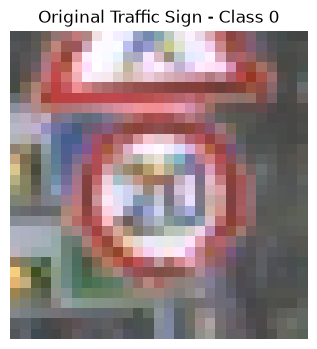

In [4]:
image_np = np.array(image)

plt.figure(figsize=(4, 4))
plt.imshow(image_np)
plt.title(f"Original Traffic Sign - Class {label}")
plt.axis("off")
plt.show()

### Convert RGB -> HSV

In [5]:
hsv_image = cv2.cvtColor(
    image_np,
    cv2.COLOR_RGB2HSV
)

print("Original image shape:", image_np.shape)
print("HSV image shape:", hsv_image.shape)

Original image shape: (30, 29, 3)
HSV image shape: (30, 29, 3)


### Separate H, S and V

In [6]:
hue, saturation, value = cv2.split(hsv_image)

print("Hue range:", hue.min(), "to", hue.max())
print("Saturation range:", saturation.min(), "to", saturation.max())
print("Value range:", value.min(), "to", value.max())

Hue range: 0 to 179
Saturation range: 0 to 198
Value range: 67 to 255


### Visualize HSV components

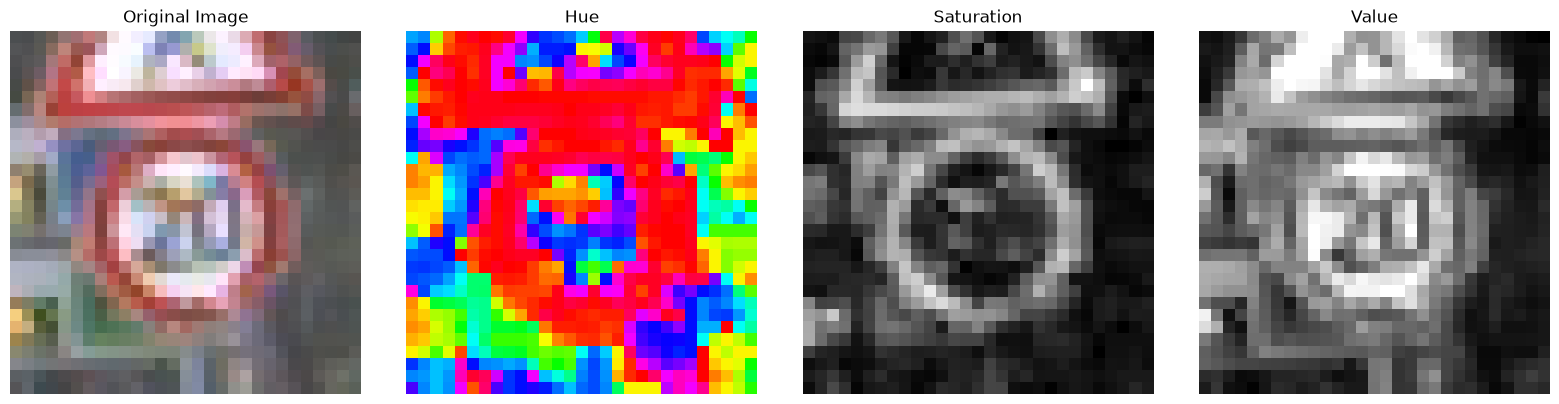

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(image_np)
axes[0].set_title("Original Image")

axes[1].imshow(hue, cmap="hsv")
axes[1].set_title("Hue")

axes[2].imshow(saturation, cmap="gray")
axes[2].set_title("Saturation")

axes[3].imshow(value, cmap="gray")
axes[3].set_title("Value")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Calculate HSV Color Histogram

In [8]:
hist = cv2.calcHist(
    [hsv_image],
    [0, 1],                 # Hue and Saturation
    None,                   # No mask
    [30, 32],               # 30 Hue bins × 32 Saturation bins
    [0, 180, 0, 256]        # H range, S range
)

print("Histogram shape:", hist.shape)

Histogram shape: (30, 32)


### Normalize the histogram

In [9]:
hist_normalized = cv2.normalize(
    hist,
    None,
    alpha=0,
    beta=1,
    norm_type=cv2.NORM_MINMAX
)

print("Minimum:", hist_normalized.min())
print("Maximum:", hist_normalized.max())

Minimum: 0.0
Maximum: 1.0


### Visualize the HSV Histogram

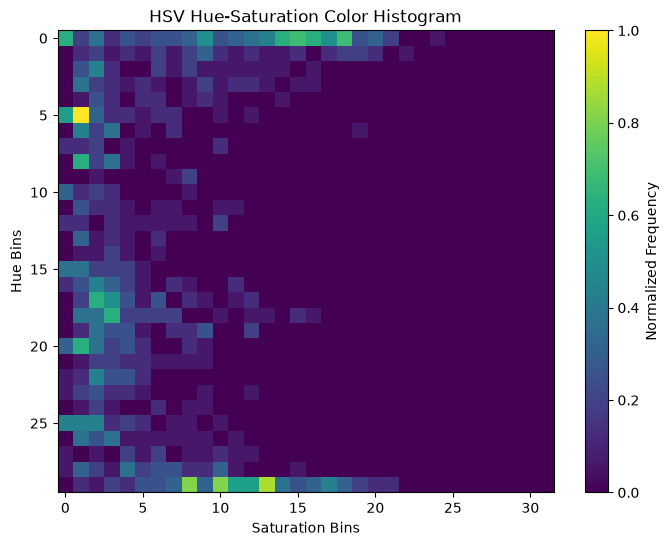

In [10]:
plt.figure(figsize=(8, 6))

plt.imshow(
    hist_normalized,
    interpolation="nearest",
    aspect="auto"
)

plt.title("HSV Hue-Saturation Color Histogram")
plt.xlabel("Saturation Bins")
plt.ylabel("Hue Bins")
plt.colorbar(label="Normalized Frequency")

plt.show()

### Convert to feature vector

In [11]:
feature_vector = hist_normalized.flatten()

print("Feature vector shape:", feature_vector.shape)
print("Number of features:", len(feature_vector))

Feature vector shape: (960,)
Number of features: 960


### Proposal-Based HSV Color Based Segmentation

In [12]:
# Function to load an image and convert it from BGR to RGB
def load_image(filepath):
    img = cv2.imread(filepath)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img
    
# Function to apply Gaussian Blur for noise reduction (using granular 3x3 kernel)
def apply_gaussian_blur(image, kernel_size=(3, 3)):
    return cv2.GaussianBlur(image, kernel_size, 0)
    
# Function to generate a normalized Red difference map using HSV color space
def get_red_diff_map(image):
    # Convert RGB to HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    
    H = hsv[:,:,0].astype(np.float32)
    S = hsv[:,:,1].astype(np.float32)
    
    # In OpenCV HSV, Hue is 0-179. Pure red is around 0 and 180.
    # Calculate distance from pure red.
    dist = np.minimum(H, 180 - H)
    
    # Map distance to a redness score (0 to 1)
    # If dist is 0 (pure red), score is 1.0. If dist >= 15 (orange/yellow), score is 0.0.
    redness = np.maximum(0, 15 - dist) / 15.0
    
    # Multiply by Saturation to ignore white/gray pixels, but be tolerant of glare.
    # If S > 80, factor is 1.0. If S < 30, factor is 0.0. This prevents glare from breaking the ring.
    sat = np.clip((S - 30) / 50.0, 0, 1)
    
    # Combine to form the difference map
    diff = redness * sat * 255.0
    
    # Normalize to 0-255 to ensure Otsu's thresholding has a full range to work with
    diff = cv2.normalize(diff, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
    
    return diff.astype(np.uint8)
    
# Function to perform adaptive thresholding (Otsu's method) on the difference map
def adaptive_color_threshold(diff_map):
    # Otsu's thresholding dynamically finds the best threshold value
    ret, mask = cv2.threshold(diff_map, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return mask

# Function to apply Morphological Cleaning (Opening first to detach noise, Closing to fill gaps)
def clean_morphology(mask):
    # Use elliptical kernels for natural rounding around circular traffic signs
    open_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    close_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    
    # Opening FIRST: Erosion followed by Dilation. This breaks thin bridges connecting background noise to the sign.
    opening = cv2.morphologyEx(mask, cv2.MORPH_OPEN, open_kernel)
    
    # Closing NEXT: Dilation followed by Erosion. An elliptical 5x5 kernel smoothly bridges gaps in the sign ring.
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, close_kernel)
    return closing
    
# Function to apply the cleaned mask to the original image, filling internal area without distortion
def extract_and_mask(image, cleaned_mask):
    # Use 4-connectivity to prevent diagonal bridges from attaching background red objects (like awnings) to the sign
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(cleaned_mask, connectivity=4)
    
    # If only background is found
    if num_labels <= 1:
        return np.zeros_like(image)
        
    # Find the label with the largest area (excluding the background which is label 0)
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    
    # Create a new mask containing only the largest connected component
    largest_mask = np.uint8(labels == largest_label) * 255
    
    # Find external contours of the isolated sign component
    contours, _ = cv2.findContours(largest_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled_mask = np.zeros_like(largest_mask)
    if contours:
        # Draw all external contours filled (-1 thickness) to include the interior area of the sign naturally
        cv2.drawContours(filled_mask, contours, -1, 255, thickness=cv2.FILLED)
    else:
        filled_mask = largest_mask
        
    # Bitwise-AND the original image with the filled mask
    result = cv2.bitwise_and(image, image, mask=filled_mask)
    return result

In [13]:
def segment_red(img, debug=False):
    """
    Proposal-based red colour segmentation
    adapted for small GTSRB images.

    Pipeline:
    BGR -> RGB -> Gaussian Blur
    -> Red Difference Map -> Otsu Threshold
    -> Morphological Cleaning -> Largest Component
    """

    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    # Step 1: Gaussian blur
    blurred = apply_gaussian_blur(
        img_rgb
    )

    # Step 2: Proposal red difference map
    diff = get_red_diff_map(
        blurred
    )

    # Step 3: Otsu adaptive threshold
    mask = adaptive_color_threshold(
        diff
    )

    # Step 4: Morphological cleaning
    # Use smaller kernels because GTSRB images are very small.
    open_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (2, 2)
    )

    close_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3, 3)
    )

    # Opening: remove small isolated noise
    opening = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        open_kernel
    )

    # Closing: connect fragmented sign regions
    cleaned = cv2.morphologyEx(
        opening,
        cv2.MORPH_CLOSE,
        close_kernel
    )

    # Step 5: Keep the largest connected component
    result = extract_and_mask(
        img_rgb,
        cleaned
    )

    # Convert result back to a binary mask
    gray = cv2.cvtColor(
        result,
        cv2.COLOR_RGB2GRAY
    )

    _, final_mask = cv2.threshold(
        gray,
        1,
        255,
        cv2.THRESH_BINARY
    )

    if debug:
        debug_images = {
            "red_difference": diff,
            "otsu_mask": mask,
            "cleaned_mask": cleaned,
            "final_mask": final_mask
        }

        return final_mask, debug_images

    return final_mask

In [14]:
def remove_small_components(binary_mask, min_area_ratio):

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        binary_mask,
        connectivity=8 #include 8 directions
    )

    cleaned_mask = np.zeros_like(binary_mask)

    image_area = binary_mask.shape[0] * binary_mask.shape[1]   #shape[0]=image height , shape[1]=image width
    min_area = image_area * min_area_ratio

    for label in range(1, num_labels):  # 0 is background

        area = stats[label, cv2.CC_STAT_AREA] #get the area of connected region

        if area >= min_area:
            cleaned_mask[labels == label] = 255

    return cleaned_mask

def enhance_img( image):

    image_cvt=cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    filtered = cv2.bilateralFilter(
        image_cvt,
        d=7,
        sigmaColor=40,
        sigmaSpace=40
    ) 


    filtered_cvt = cv2.cvtColor(filtered,cv2.COLOR_RGB2HSV)



    h, s, v = cv2.split(filtered_cvt)


    hue_mask = cv2.inRange(
        h,
        99,
        125
    )
    
    
    # Adaptive thresholding on Saturation
    saturation_mask = cv2.adaptiveThreshold(
        s,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        91,
        2
    )
    
    
    value_mask = cv2.inRange(
        v,
        42,
        255
    )
    
    # Combine Hue, Saturation and Value masks
    blue_mask = cv2.bitwise_and(
        hue_mask,
        saturation_mask
    )
    
    blue_mask = cv2.bitwise_and(
        blue_mask,
        value_mask
    )

    blue_mask = remove_small_components(
    blue_mask,
    min_area_ratio=0.05
    )


    # Morphological closing:
    # connects nearby white regions and fills small black gaps
    closing_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (4,4)
    )

    final_mask = cv2.morphologyEx(
        blue_mask,
        cv2.MORPH_CLOSE,
        closing_kernel,
        iterations=1
    )

   
 
    return blue_mask , filtered, final_mask




def get_filled_contour_mask(binary_image):

    contours, hierarchy = cv2.findContours(
        binary_image,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return np.zeros_like(binary_image)

    contour_mask = np.zeros_like(binary_image)
    

    # Select the largest contour as the traffic sign
    largest_contour = max(
        contours,
        key=cv2.contourArea
    )
    
    hull = cv2.convexHull(largest_contour)

    cv2.drawContours(
        contour_mask,
        [hull],  #cv2.drawContours() expects a collection of contours
        -1,
        255,
        thickness=cv2.FILLED  #thickness: fill the contour
    )

    return contour_mask

In [15]:
def segment_blue(img, debug=False):

    blue_mask, filtered, final_mask = enhance_img(img)

    contour_mask = get_filled_contour_mask(final_mask)

    if debug:
        debug_images = {
            "filtered": filtered,
            "threshold": final_mask,
            "filled": contour_mask
        }
        return contour_mask, debug_images

    return contour_mask

In [16]:
# Enhance dark images using CLAHE
def clean_dark_image(
    image,
    brightness_threshold=140,
    clahe_clip_limit=2.0,
    clahe_grid_size=(8, 8)
):
    cleaned_image = image.copy()

    hsv_image = cv2.cvtColor(cleaned_image, cv2.COLOR_BGR2HSV)
    h_channel, s_channel, v_channel = cv2.split(hsv_image)

    height, width = v_channel.shape

    # Check the brightness near the image centre
    centre_region = v_channel[
        height // 4: 3 * height // 4,
        width // 4: 3 * width // 4
    ]

    mean_brightness = float(np.mean(centre_region))

    # Enhance dark images using CLAHE
    if mean_brightness < brightness_threshold:
        clahe = cv2.createCLAHE(
            clipLimit=clahe_clip_limit,
            tileGridSize=clahe_grid_size
        )

        enhanced_v = clahe.apply(v_channel)
        enhanced_hsv = cv2.merge(
            (h_channel, s_channel, enhanced_v)
        )

        cleaned_image = cv2.cvtColor(
            enhanced_hsv,
            cv2.COLOR_HSV2BGR
        )

    return cleaned_image


# Set a valid block size for adaptive thresholding
def get_valid_block_size(
    image, 
    preferred_size=51
):
    block_size = min(
        preferred_size,
        min(image.shape[:2])
    )

    if block_size % 2 == 0:
        block_size -= 1

    if block_size < 3:
        raise ValueError(
            "The image is too small for adaptive thresholding."
        )

    return block_size


# Create the combined yellow mask
def create_combined_threshold(
    cleaned_image,
    lower_yellow=(5, 80, 30),
    upper_yellow=(40, 255, 255),
    adaptive_block_size=51,
    adaptive_c=7
):
    hsv_image = cv2.cvtColor(
        cleaned_image,
        cv2.COLOR_BGR2HSV
    )

    _, _, v_channel = cv2.split(hsv_image)
    
    lower_bound = np.array(
        lower_yellow,
        dtype=np.uint8
    )

    upper_bound = np.array(
        upper_yellow,
        dtype=np.uint8
    )

    # Extract yellow pixels using the HSV range
    yellow_mask = cv2.inRange(
        hsv_image,
        lower_bound,
        upper_bound
    )

    block_size = get_valid_block_size(
        v_channel,
        adaptive_block_size
    )

    # Apply adaptive thresholding for uneven lighting
    adaptive_image = cv2.adaptiveThreshold(
        v_channel,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        block_size,
        adaptive_c
    )

    # Combine the colour and threshold masks
    combined_threshold = cv2.bitwise_and(
        yellow_mask,
        adaptive_image
    )

    return combined_threshold


# Clean the mask using morphological closing
def apply_morphological_closing(
    combined_threshold,
    kernel_size=(3, 3),
    iterations=1
):
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        kernel_size
    )

    # Connect broken regions and fill small gaps
    morphological_image = cv2.morphologyEx(
        combined_threshold,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=iterations
    )

    return morphological_image


# Select the best traffic-sign contour
def select_best_contour(
    morphological_image,
    min_area_ratio=0.005,
    max_area_ratio=0.75
):
    height, width = morphological_image.shape
    image_area = height * width

    image_centre_x = width / 2
    image_centre_y = height / 2

    # Find the outer contours
    contours, _ = cv2.findContours(
        morphological_image.copy(),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    best_contour = None
    best_score = -1

    for contour in contours:
        contour_area = cv2.contourArea(contour)

        # Remove contours that are too small or too large
        if not (
            image_area * min_area_ratio
            <= contour_area
            <= image_area * max_area_ratio
        ):
            continue

        moments = cv2.moments(contour)

        if moments["m00"] == 0:
            continue

        contour_centre_x = (
            moments["m10"] / moments["m00"]
        )

        contour_centre_y = (
            moments["m01"] / moments["m00"]
        )

        centre_distance = np.hypot(
            contour_centre_x - image_centre_x,
            contour_centre_y - image_centre_y
        )

        # Prefer a large contour near the image centre
        contour_score = (
            contour_area / (centre_distance + 1)
        )

        if contour_score > best_score:
            best_contour = contour
            best_score = contour_score

    return best_contour


# Reconstruct an incomplete outer contour
def reconstruct_outer_contour(
    selected_contour,
    solidity_threshold=0.90,
    approximation_ratio=0.01
):
    if selected_contour is None:
        return None

    contour_area = cv2.contourArea(
        selected_contour
    )

    # Create a convex hull around the contour
    convex_hull = cv2.convexHull(
        selected_contour
    )

    hull_area = cv2.contourArea(
        convex_hull
    )

    if hull_area == 0:
        return selected_contour

    solidity = contour_area / hull_area

    # Reconstruct the boundary if the contour is incomplete
    if solidity < solidity_threshold:
        hull_perimeter = cv2.arcLength(
            convex_hull,
            True
        )

        return cv2.approxPolyDP(
            convex_hull,
            approximation_ratio * hull_perimeter,
            True
        )

    return selected_contour


# Create the contour and segmentation outputs
def create_contour_outputs(
    original_image,
    selected_contour
):
    # Create an image for displaying the green contour
    contour_only_image = np.zeros_like(
        original_image
    )

    # Create the filled contour mask
    contour_mask = np.zeros(
        original_image.shape[:2],
        dtype=np.uint8
    )

    # Return empty results if no contour is found
    if selected_contour is None:

        segmented_original = np.zeros_like(
            original_image
        )

        return (
            contour_only_image,
            contour_mask,
            segmented_original
        )

    # Reconstruct the outer boundary
    outer_contour = reconstruct_outer_contour(
        selected_contour
    )

    # Draw the detected contour
    cv2.drawContours(
        contour_only_image,
        [outer_contour],
        -1,
        (0, 255, 0),
        2
    )

    # Fill the detected contour
    cv2.drawContours(
        contour_mask,
        [outer_contour],
        -1,
        255,
        cv2.FILLED
    )

    # Extract the traffic-sign region
    segmented_original = cv2.bitwise_and(
        original_image,
        original_image,
        mask=contour_mask
    )

    return (
        contour_only_image,
        contour_mask,
        segmented_original
    )


In [17]:
def segment_yellow(img, debug=False):

    cleaned = clean_dark_image(img)

    threshold = create_combined_threshold(cleaned)

    morph = apply_morphological_closing(threshold)

    contour = select_best_contour(morph)

    _, contour_mask, _ = create_contour_outputs(
        img,
        contour
    )

    if debug:
        debug_images = {
            "filtered": cleaned,
            "threshold": threshold,
            "filled": contour_mask
        }
        return contour_mask, debug_images

    return contour_mask

In [18]:
def find_best_contour(mask):
    """
    Select the best traffic-sign contour from a binary mask.

    Adapted for the small GTSRB image dimensions.
    Candidate contours are filtered by a small minimum
    area and scored using area, circularity and solidity.
    """

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return None

    best_contour = None
    best_score = 0

    # GTSRB images are very small, so use a small
    # absolute minimum contour area.
    MIN_AREA = 3.0

    for contour in contours:

        area = cv2.contourArea(contour)

        # Reject extremely small noise
        if area < MIN_AREA:
            continue

        perimeter = cv2.arcLength(
            contour,
            True
        )

        if perimeter == 0:
            continue

        # Circularity
        circularity = (
            4 * np.pi * area
            / (perimeter ** 2)
        )

        # Convex hull
        hull = cv2.convexHull(contour)

        hull_area = cv2.contourArea(hull)

        if hull_area == 0:
            continue

        # Solidity
        solidity = area / hull_area

        # Proposal-based contour score
        score = (
            area
            * circularity
            * solidity
        )

        if score > best_score:

            best_score = score
            best_contour = contour

    return best_contour

### Test the proposal segmentation on 1 image

In [19]:
# Convert GTSRB PIL/RGB image to OpenCV BGR format
image_np = np.array(image)

image_bgr = cv2.cvtColor(
    image_np,
    cv2.COLOR_RGB2BGR
)

# Apply the three segmentation methods
red_mask = segment_red(image_bgr)
blue_mask = segment_blue(image_bgr)
yellow_mask = segment_yellow(image_bgr)

print("Red mask:", red_mask.shape)
print("Blue mask:", blue_mask.shape)
print("Yellow mask:", yellow_mask.shape)

Red mask: (30, 29)
Blue mask: (30, 29)
Yellow mask: (30, 29)


### Combine 3 masks

In [20]:
combined_mask = cv2.bitwise_or(
    red_mask,
    blue_mask
)

combined_mask = cv2.bitwise_or(
    combined_mask,
    yellow_mask
)

print(
    "Combined mask pixels:",
    np.count_nonzero(combined_mask)
)

Combined mask pixels: 351


### Visualize the masks

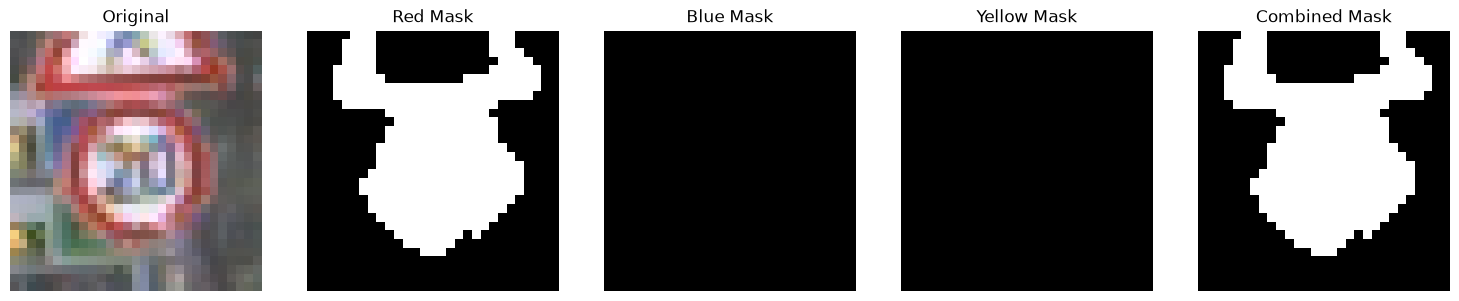

In [21]:
fig, axes = plt.subplots(
    1, 5,
    figsize=(15, 3)
)

axes[0].imshow(image_np)
axes[0].set_title("Original")

axes[1].imshow(red_mask, cmap="gray")
axes[1].set_title("Red Mask")

axes[2].imshow(blue_mask, cmap="gray")
axes[2].set_title("Blue Mask")

axes[3].imshow(yellow_mask, cmap="gray")
axes[3].set_title("Yellow Mask")

axes[4].imshow(combined_mask, cmap="gray")
axes[4].set_title("Combined Mask")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Extract ROI from the combined mask

In [22]:
def extract_roi_from_mask(image, mask):
    """
    Extract the traffic-sign ROI using the proposal's
    contour-selection approach.

    The best contour is selected using the existing
    area, circularity and solidity scoring method.
    """

    best_contour = find_best_contour(mask)

    if best_contour is None:
        return None, None, None

    x, y, w, h = cv2.boundingRect(best_contour)

    if w <= 0 or h <= 0:
        return None, None, None

    roi = image[
        y:y+h,
        x:x+w
    ]

    return roi, (x, y, w, h), best_contour

In [23]:
roi, bbox, best_contour = extract_roi_from_mask(
    image_np,
    combined_mask
)

if roi is None:
    print("No valid traffic-sign ROI detected.")
else:
    print("ROI shape:", roi.shape)
    print("Bounding box:", bbox)

ROI shape: (26, 24, 3)
Bounding box: (3, 0, 24, 26)


### Visualize the final ROI

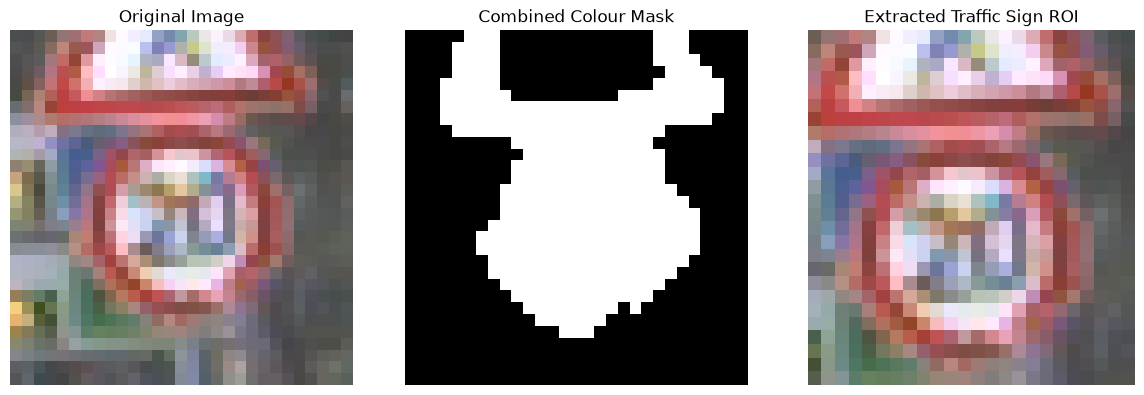

In [24]:
if roi is not None:

    fig, axes = plt.subplots(
        1, 3,
        figsize=(12, 4)
    )

    # Original
    axes[0].imshow(image_np)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    # Combined mask
    axes[1].imshow(
        combined_mask,
        cmap="gray"
    )
    axes[1].set_title("Combined Colour Mask")
    axes[1].axis("off")

    # ROI
    axes[2].imshow(roi)
    axes[2].set_title("Extracted Traffic Sign ROI")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

### HSV Histogram using the proposal segmentation mask

In [25]:
def extract_masked_hsv_histogram(image, mask):
    """
    Extract a normalized Hue-Saturation histogram
    using only pixels inside the traffic-sign mask.
    """

    hsv = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2HSV
    )

    hist = cv2.calcHist(
        [hsv],
        [0, 1],
        mask,
        [30, 32],
        [0, 180, 0, 256]
    )

    hist = cv2.normalize(
        hist,
        None,
        alpha=0,
        beta=1,
        norm_type=cv2.NORM_MINMAX
    )

    feature_vector = hist.flatten()

    return hist, feature_vector

In [26]:
if np.count_nonzero(combined_mask) > 0:

    roi_hist, roi_feature_vector = (
        extract_masked_hsv_histogram(
            image_np,
            combined_mask
        )
    )

    print(
        "Feature vector shape:",
        roi_feature_vector.shape
    )

    print(
        "Number of features:",
        len(roi_feature_vector)
    )

Feature vector shape: (960,)
Number of features: 960


### Visualize the final feature extraction

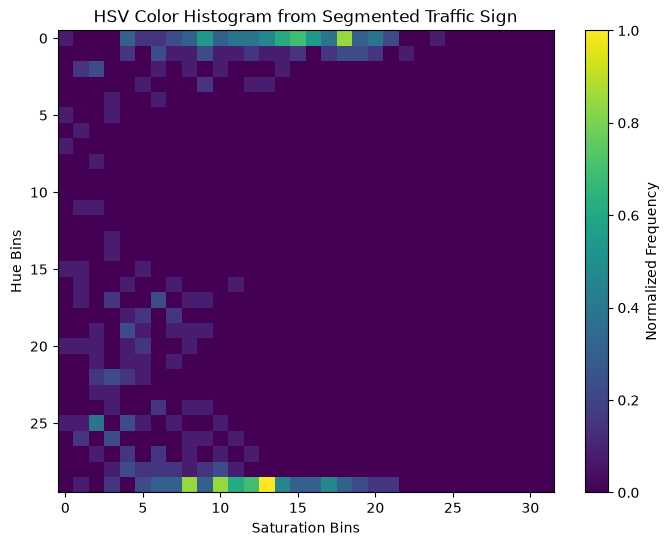

In [27]:
plt.figure(figsize=(8, 6))

plt.imshow(
    roi_hist,
    interpolation="nearest",
    aspect="auto"
)

plt.title(
    "HSV Color Histogram from Segmented Traffic Sign"
)

plt.xlabel("Saturation Bins")
plt.ylabel("Hue Bins")

plt.colorbar(
    label="Normalized Frequency"
)

plt.show()

### Test Proposal Segmentation on 10 Traffic Sign Images

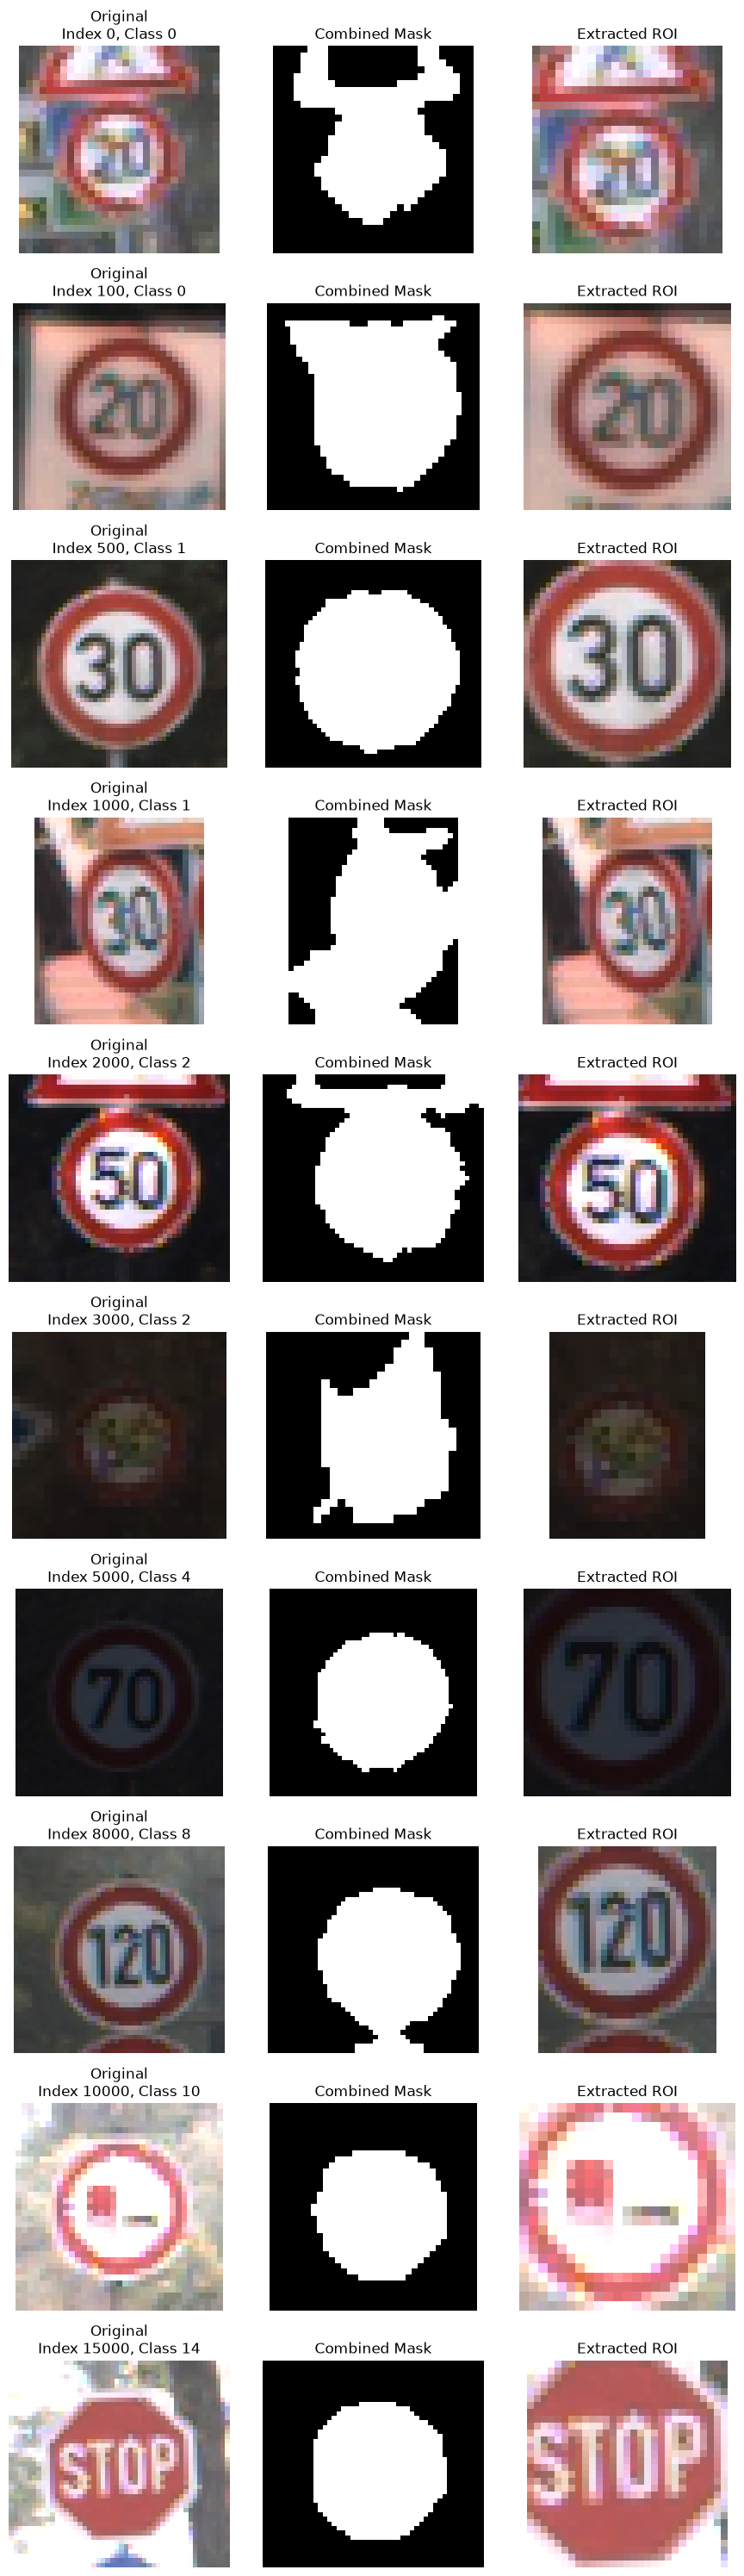

In [28]:
# Select 10 different GTSRB training images
sample_indices = [
    0, 100, 500, 1000, 2000,
    3000, 5000, 8000, 10000, 15000
]

fig, axes = plt.subplots(
    10, 3,
    figsize=(9, 30)
)

for row, index in enumerate(sample_indices):

    # Load image and label
    image, label = train_dataset[index]

    image_np = np.array(image)

    # Convert RGB → BGR for proposal segmentation
    image_bgr = cv2.cvtColor(
        image_np,
        cv2.COLOR_RGB2BGR
    )

    # Proposal colour segmentation
    red_mask = segment_red(image_bgr)
    blue_mask = segment_blue(image_bgr)
    yellow_mask = segment_yellow(image_bgr)

    # Combine masks
    combined_mask = cv2.bitwise_or(
        red_mask,
        blue_mask
    )

    combined_mask = cv2.bitwise_or(
        combined_mask,
        yellow_mask
    )

    # Proposal contour selection + ROI
    roi, bbox, best_contour = extract_roi_from_mask(
        image_np,
        combined_mask
    )

    # Original
    axes[row, 0].imshow(image_np)
    axes[row, 0].set_title(
        f"Original\nIndex {index}, Class {label}"
    )
    axes[row, 0].axis("off")

    # Combined mask
    axes[row, 1].imshow(
        combined_mask,
        cmap="gray"
    )
    axes[row, 1].set_title("Combined Mask")
    axes[row, 1].axis("off")

    # ROI
    if roi is not None:

        axes[row, 2].imshow(roi)
        axes[row, 2].set_title("Extracted ROI")

    else:

        axes[row, 2].text(
            0.5,
            0.5,
            "No ROI detected",
            ha="center",
            va="center"
        )

        axes[row, 2].set_title("Extracted ROI")

    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

### Preliminary ROI Recognition Rate (10 Images)

In [29]:
detected = 0
total = len(sample_indices)

for index in sample_indices:

    image, label = train_dataset[index]

    image_np = np.array(image)

    image_bgr = cv2.cvtColor(
        image_np,
        cv2.COLOR_RGB2BGR
    )

    # Proposal colour segmentation
    red_mask = segment_red(image_bgr)
    blue_mask = segment_blue(image_bgr)
    yellow_mask = segment_yellow(image_bgr)

    # Combine masks
    combined_mask = cv2.bitwise_or(
        red_mask,
        blue_mask
    )

    combined_mask = cv2.bitwise_or(
        combined_mask,
        yellow_mask
    )

    # Proposal contour selection
    roi, bbox, best_contour = extract_roi_from_mask(
        image_np,
        combined_mask
    )

    if roi is not None:
        detected += 1

detection_rate = (
    detected / total
) * 100

print(f"Detected ROIs: {detected}")
print(f"Total images: {total}")
print(f"ROI detection rate: {detection_rate:.2f}%")

Detected ROIs: 10
Total images: 10
ROI detection rate: 100.00%


### Manually Verified ROI Recognition Rate

All 10 extracted ROIs were visually inspected and confirmed to contain the correct traffic sign.

Recognition Rate = (10 / 10) × 100% = 100%

In [30]:
correct = 10
total = 10

recognition_rate = (
    correct / total
) * 100

print(f"Correctly extracted images: {correct}")
print(f"Total images: {total}")
print(f"Recognition rate: {recognition_rate:.2f}%")

Correctly extracted images: 10
Total images: 10
Recognition rate: 100.00%


## Full Dataset HSV Feature Extraction

In [31]:
def extract_hsv_features_from_image(image):
    """
    Extract a 960-dimensional HSV colour histogram
    using the proposal-based colour segmentation
    and contour selection.
    """

    # Convert PIL image to NumPy RGB
    image_np = np.array(image)

    # Convert RGB → BGR for proposal segmentation
    image_bgr = cv2.cvtColor(
        image_np,
        cv2.COLOR_RGB2BGR
    )

    # Proposal colour segmentation
    red_mask = segment_red(image_bgr)
    blue_mask = segment_blue(image_bgr)
    yellow_mask = segment_yellow(image_bgr)

    # Combine colour masks
    combined_mask = cv2.bitwise_or(
        red_mask,
        blue_mask
    )

    combined_mask = cv2.bitwise_or(
        combined_mask,
        yellow_mask
    )

    # Check whether any colour region exists
    if np.count_nonzero(combined_mask) == 0:
        return None

    # Find best contour
    best_contour = find_best_contour(
        combined_mask
    )

    if best_contour is None:
        return None

    # Create a clean mask containing only the selected contour
    selected_mask = np.zeros_like(
        combined_mask
    )

    cv2.drawContours(
        selected_mask,
        [best_contour],
        -1,
        255,
        thickness=-1
    )

    # Extract HSV histogram from selected region
    hsv = cv2.cvtColor(
        image_np,
        cv2.COLOR_RGB2HSV
    )

    hist = cv2.calcHist(
        [hsv],
        [0, 1],
        selected_mask,
        [30, 32],
        [0, 180, 0, 256]
    )

    # Normalize
    hist = cv2.normalize(
        hist,
        None,
        alpha=0,
        beta=1,
        norm_type=cv2.NORM_MINMAX
    )

    # Flatten → 960 features
    feature_vector = hist.flatten()

    return feature_vector

### Test the final function on 1 image

In [32]:
test_features = extract_hsv_features_from_image(
    train_dataset[0][0]
)

if test_features is None:
    print("Feature extraction failed.")
else:
    print("Feature vector shape:", test_features.shape)
    print("Number of features:", len(test_features))



Feature vector shape: (960,)
Number of features: 960


### Test the final function on the same 10 images

In [33]:
successful = 0

for index in sample_indices:

    image, label = train_dataset[index]

    features = extract_hsv_features_from_image(
        image
    )

    if features is not None:
        successful += 1

print(
    f"Successful feature extraction: "
    f"{successful}/{len(sample_indices)}"
)

print(
    f"Feature extraction rate: "
    f"{successful / len(sample_indices) * 100:.2f}%"
)

Successful feature extraction: 10/10
Feature extraction rate: 100.00%


## Extract HSV Features from the Full Training Dataset

In [34]:
X_train = []
y_train = []

failed_train_indices = []

total_train = len(train_dataset)

for index in range(total_train):

    image, label = train_dataset[index]

    features = extract_hsv_features_from_image(image)

    if features is not None:
        X_train.append(features)
        y_train.append(label)
    else:
        failed_train_indices.append(index)

    # Show progress every 1000 images
    if (index + 1) % 1000 == 0:
        print(
            f"Processed {index + 1}/{total_train} images"
        )

# Convert to NumPy arrays
X_train = np.array(
    X_train,
    dtype=np.float32
)

y_train = np.array(
    y_train,
    dtype=np.int64
)

print("\nTraining feature extraction complete.")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Failed images:", len(failed_train_indices))

Processed 1000/26640 images
Processed 2000/26640 images
Processed 3000/26640 images
Processed 4000/26640 images
Processed 5000/26640 images
Processed 6000/26640 images
Processed 7000/26640 images
Processed 8000/26640 images
Processed 9000/26640 images
Processed 10000/26640 images
Processed 11000/26640 images
Processed 12000/26640 images
Processed 13000/26640 images
Processed 14000/26640 images
Processed 15000/26640 images
Processed 16000/26640 images
Processed 17000/26640 images
Processed 18000/26640 images
Processed 19000/26640 images
Processed 20000/26640 images
Processed 21000/26640 images
Processed 22000/26640 images
Processed 23000/26640 images
Processed 24000/26640 images
Processed 25000/26640 images
Processed 26000/26640 images

Training feature extraction complete.
X_train shape: (26004, 960)
y_train shape: (26004,)
Failed images: 636


### Training Feature Matrix

In [35]:
print("Training feature matrix:")
print("Number of images:", X_train.shape[0])
print("Number of features per image:", X_train.shape[1])

print("\nLabels:")
print("Number of labels:", len(y_train))

print("\nFailed image count:", len(failed_train_indices))

Training feature matrix:
Number of images: 26004
Number of features per image: 960

Labels:
Number of labels: 26004

Failed image count: 636


### Save Training Feature Vectors

In [36]:
FEATURE_DIR = Path("../features")
FEATURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

np.savez_compressed(
    FEATURE_DIR / "gtsrb_hsv_features_train.npz",
    X=X_train,
    y=y_train
)

print(
    "Saved training features to:",
    FEATURE_DIR / "gtsrb_hsv_features_train.npz"
)

Saved training features to: ..\features\gtsrb_hsv_features_train.npz


## Extract HSV Features from the Full Test Dataset

In [37]:
X_test = []
y_test = []

failed_test_indices = []

total_test = len(test_dataset)

for index in range(total_test):

    image, label = test_dataset[index]

    features = extract_hsv_features_from_image(image)

    if features is not None:
        X_test.append(features)
        y_test.append(label)
    else:
        failed_test_indices.append(index)

    # Show progress every 1000 images
    if (index + 1) % 1000 == 0:
        print(
            f"Processed {index + 1}/{total_test} images"
        )

# Convert to NumPy arrays
X_test = np.array(
    X_test,
    dtype=np.float32
)

y_test = np.array(
    y_test,
    dtype=np.int64
)

print("\nTest feature extraction complete.")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Failed images:", len(failed_test_indices))

Processed 1000/12630 images
Processed 2000/12630 images
Processed 3000/12630 images
Processed 4000/12630 images
Processed 5000/12630 images
Processed 6000/12630 images
Processed 7000/12630 images
Processed 8000/12630 images
Processed 9000/12630 images
Processed 10000/12630 images
Processed 11000/12630 images
Processed 12000/12630 images

Test feature extraction complete.
X_test shape: (12261, 960)
y_test shape: (12261,)
Failed images: 369


In [38]:
train_success_rate = (
    len(X_train) / len(train_dataset)
) * 100

print(
    f"Final training extraction success rate: "
    f"{train_success_rate:.2f}%"
)

Final training extraction success rate: 97.61%


In [39]:
test_success_rate = (
    len(X_test) / len(test_dataset)
) * 100

print(
    f"Final testing extraction success rate: "
    f"{test_success_rate:.2f}%"
)

Final testing extraction success rate: 97.08%


## Assignment 1 Input Images — Required Testing Set

The Assignment 1 input images are used as the primary testing set as
specified in the project requirements. The images are organized into
Blue Signs, Red signs, and Yellow Signs folders.

The same HSV colour histogram feature extraction pipeline used for the
GTSRB dataset is applied to these images.

The GTSRB test set is retained as an additional testing dataset.

In [41]:
from pathlib import Path
from PIL import Image
import numpy as np
import cv2

# Assignment 1 input directory
INPUT_DIR = Path("../data/Inputs")

print("Assignment 1 input directory:")
print(INPUT_DIR.resolve())

# Collect all image files recursively
assignment1_images = sorted(
    [
        p for p in INPUT_DIR.rglob("*")
        if p.suffix.lower() in {
            ".jpg",
            ".jpeg",
            ".png",
            ".bmp"
        }
    ]
)

print(
    f"\nAssignment 1 images found: "
    f"{len(assignment1_images)}"
)

# Show number of images in each folder
for folder in sorted(INPUT_DIR.iterdir()):

    if folder.is_dir():

        count = sum(
            1
            for p in folder.rglob("*")
            if p.suffix.lower() in {
                ".jpg",
                ".jpeg",
                ".png",
                ".bmp"
            }
        )

        print(
            f"{folder.name}: {count} images"
        )

Assignment 1 input directory:
C:\Users\Sova\Desktop\traffic-sign-recognition\data\Inputs

Assignment 1 images found: 84
Blue Signs: 28 images
Red signs: 28 images
Yellow Signs: 28 images


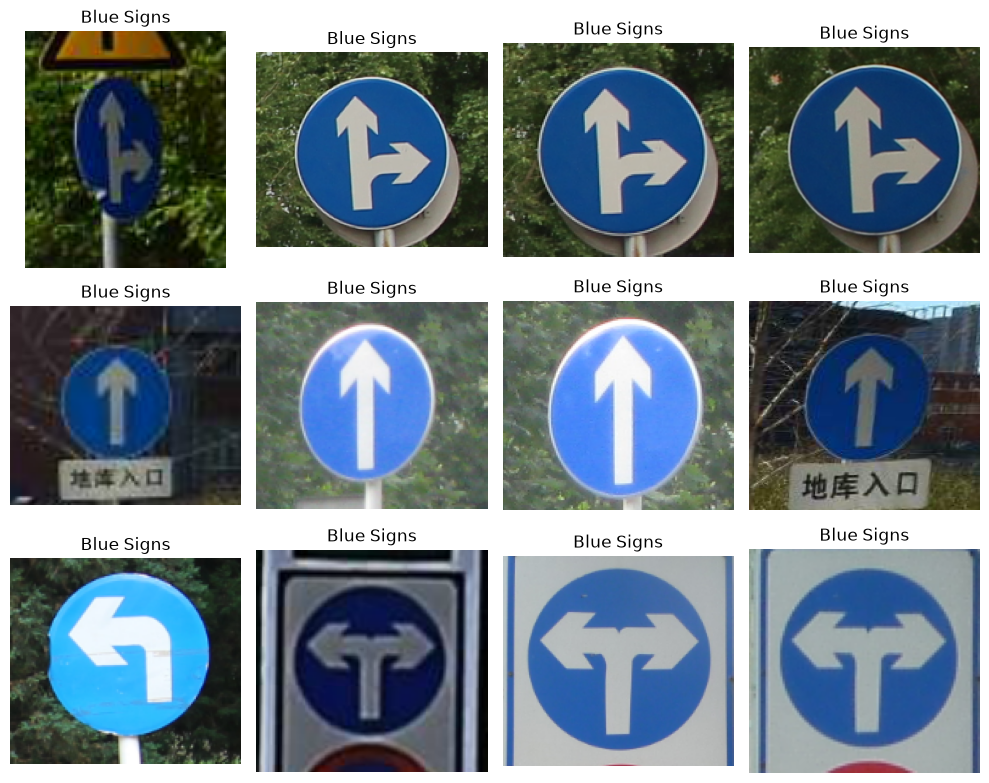

In [42]:
# Visualize a sample of Assignment 1 input images

sample_paths = assignment1_images[:12]

fig, axes = plt.subplots(
    3,
    4,
    figsize=(10, 8)
)

axes = axes.flatten()

for ax, image_path in zip(
    axes,
    sample_paths
):

    image = Image.open(
        image_path
    ).convert("RGB")

    ax.imshow(image)

    ax.set_title(
        image_path.parent.name
    )

    ax.axis("off")

for ax in axes[len(sample_paths):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### HSV Feature Extraction on Assignment 1 Images

In [47]:
# Extract the same 960-dimensional HSV features
# used for the GTSRB training and testing datasets.

X_assignment1 = []
assignment1_failed = []

total_assignment1 = len(
    assignment1_images
)

for image_path in assignment1_images:

    try:

        # Load image as RGB PIL image
        image = Image.open(
            image_path
        ).convert("RGB")

        # Use the finalized feature extraction pipeline
        features = extract_hsv_features_from_image(
            image
        )

        if features is not None:

            X_assignment1.append(
                features
            )

        else:

            assignment1_failed.append(
                str(image_path)
            )

    except Exception as e:

        assignment1_failed.append(
            f"{image_path} | {e}"
        )


# Convert to NumPy array
X_assignment1 = np.array(
    X_assignment1,
    dtype=np.float32
)

assignment1_success_rate = (
    len(X_assignment1)
    / total_assignment1
) * 100

print(
    "\nAssignment 1 feature extraction complete."
)

print(
    "Total images:",
    total_assignment1
)

print(
    "Successful:",
    len(X_assignment1)
)

print(
    "Failed:",
    len(assignment1_failed)
)

print(
    "Success rate:",
    f"{assignment1_success_rate:.2f}%"
)

print(
    "Feature vector shape:",
    X_assignment1.shape
)


Assignment 1 feature extraction complete.
Total images: 84
Successful: 84
Failed: 0
Success rate: 100.00%
Feature vector shape: (84, 960)


### Save Assignment 1 Test Feature Vectors

In [48]:
assignment1_output = (
    FEATURE_DIR / "assignment1_test_hsv_features.npz"
)

np.savez_compressed(
    assignment1_output,
    X=X_assignment1,
    image_paths=np.array(
        [
            str(p)
            for p in assignment1_images
        ]
    )
)

print(
    "Saved Assignment 1 feature vectors to:"
)

print(
    assignment1_output.resolve()
)

Saved Assignment 1 feature vectors to:
C:\Users\Sova\Desktop\traffic-sign-recognition\features\assignment1_test_hsv_features.npz


## Final Feature Extraction Results

The final HSV colour histogram feature extraction produces **960 features per image** using a 30 × 32 Hue-Saturation histogram.

| Dataset | Total Images | Successful Extraction | Failed | Success Rate |
|---|---:|---:|---:|---:|
| GTSRB Training | 26,640 | 26,004 | 636 | **97.61%** |
| GTSRB Testing | 12,630 | 12,261 | 369 | **97.08%** |
| Assignment 1 Testing | 84 | 84 | 0 | **100.00%** |

The Assignment 1 input images are used as the required testing set. The GTSRB test set is retained as an additional testing dataset.

All successfully extracted images are represented using the same **960-dimensional HSV feature vector** and saved as compressed `.npz` files for the classification stage.

### Save Test Feature Vectors

In [40]:
np.savez_compressed(
    FEATURE_DIR / "gtsrb_hsv_features_test.npz",
    X=X_test,
    y=y_test
)

print(
    "Saved test features to:",
    FEATURE_DIR / "gtsrb_hsv_features_test.npz"
)

Saved test features to: ..\features\gtsrb_hsv_features_test.npz
